In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Load final dataset
df = pd.read_csv("../data/processed/final_features.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

# Separate features and target
X = df.drop(columns=["NObeyesdad"])
y = df["NObeyesdad"]

# Define feature types
numerical_features = [
    "Age", "Height", "Weight", "FCVC",
    "NCP", "CH2O", "FAF", "TUE"
]

categorical_features = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "CAEC",
    "SMOKE",
    "SCC",
    "CALC",
    "MTRANS"
]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create preprocessing pipeline
numerical_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nProcessed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Dataset loaded successfully!
Shape: (2087, 17)

Training data: (1669, 16)
Testing data: (418, 16)

Processed training data: (1669, 31)
Processed testing data: (418, 31)


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_processed)

# Calculate accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression trained successfully!")
print("Test Accuracy:", round(logistic_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression trained successfully!
Test Accuracy: 89.71 %

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        53
      Normal_Weight       0.84      0.82      0.83        57
     Obesity_Type_I       0.92      0.93      0.92        70
    Obesity_Type_II       0.94      1.00      0.97        60
   Obesity_Type_III       0.98      0.98      0.98        65
 Overweight_Level_I       0.80      0.80      0.80        55
Overweight_Level_II       0.82      0.72      0.77        58

           accuracy                           0.90       418
          macro avg       0.89      0.89      0.89       418
       weighted avg       0.89      0.90      0.90       418



In [3]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train_processed, y_train)

# Make predictions
y_pred_tree = decision_tree_model.predict(X_test_processed)

# Calculate accuracy
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree trained successfully!")
print("Test Accuracy:", round(tree_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree trained successfully!
Test Accuracy: 93.3 %

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.96      0.97        53
      Normal_Weight       0.83      0.91      0.87        57
     Obesity_Type_I       0.94      0.94      0.94        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.88      0.76      0.82        55
Overweight_Level_II       0.92      0.97      0.94        58

           accuracy                           0.93       418
          macro avg       0.93      0.93      0.93       418
       weighted avg       0.93      0.93      0.93       418



In [4]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train_processed, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test_processed)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest trained successfully!")
print("Number of trees:", 300)
print("Test Accuracy:", round(rf_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest trained successfully!
Number of trees: 300
Test Accuracy: 94.26 %

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        53
      Normal_Weight       0.79      0.93      0.85        57
     Obesity_Type_I       1.00      0.96      0.98        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.90      0.85      0.88        55
Overweight_Level_II       0.93      0.91      0.92        58

           accuracy                           0.94       418
          macro avg       0.94      0.94      0.94       418
       weighted avg       0.95      0.94      0.94       418



In [5]:
# Compare training and test performance

train_pred_rf = random_forest_model.predict(X_train_processed)

train_accuracy_rf = accuracy_score(y_train, train_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("Training Accuracy:", round(train_accuracy_rf * 100, 2), "%")
print("Test Accuracy:    ", round(rf_accuracy * 100, 2), "%")
print("Accuracy Gap:     ", round((train_accuracy_rf - rf_accuracy) * 100, 2), "percentage points")

Random Forest Performance
-------------------------
Training Accuracy: 100.0 %
Test Accuracy:     94.26 %
Accuracy Gap:      5.74 percentage points


In [6]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on the training data only
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Random Forest - 5-Fold Cross-Validation")
print("---------------------------------------")

for i, score in enumerate(rf_cv_scores, start=1):
    print(f"Fold {i} Accuracy: {score * 100:.2f}%")

print("\nMean CV Accuracy:", round(rf_cv_scores.mean() * 100, 2), "%")
print("CV Standard Deviation:", round(rf_cv_scores.std() * 100, 2), "%")

Random Forest - 5-Fold Cross-Validation
---------------------------------------
Fold 1 Accuracy: 94.91%
Fold 2 Accuracy: 90.12%
Fold 3 Accuracy: 96.11%
Fold 4 Accuracy: 91.62%
Fold 5 Accuracy: 94.59%

Mean CV Accuracy: 93.47 %
CV Standard Deviation: 2.23 %


In [7]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter combinations to test
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 15, 25],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Create a fresh Random Forest
rf_for_tuning = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Grid search using training data only
grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_processed, y_train)

print("\nRandom Forest tuning completed!")
print("Best CV Accuracy:", round(grid_search.best_score_ * 100, 2), "%")
print("Best Parameters:")
print(grid_search.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Random Forest tuning completed!
Best CV Accuracy: 93.47 %
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [8]:
# Get the best Random Forest found by GridSearchCV
best_rf_model = grid_search.best_estimator_

# Predict on the untouched test set
y_pred_best_rf = best_rf_model.predict(X_test_processed)

# Final test accuracy
best_rf_test_accuracy = accuracy_score(y_test, y_pred_best_rf)

print("Tuned Random Forest - Final Test Evaluation")
print("--------------------------------------------")
print("Test Accuracy:", round(best_rf_test_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

Tuned Random Forest - Final Test Evaluation
--------------------------------------------
Test Accuracy: 93.3 %

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        53
      Normal_Weight       0.75      0.91      0.83        57
     Obesity_Type_I       0.99      0.97      0.98        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.92      0.82      0.87        55
Overweight_Level_II       0.89      0.88      0.89        58

           accuracy                           0.93       418
          macro avg       0.94      0.93      0.93       418
       weighted avg       0.94      0.93      0.93       418



In [9]:
try:
    import xgboost as xgb
    print("XGBoost is installed!")
    print("XGBoost version:", xgb.__version__)
except ImportError:
    print("XGBoost is NOT installed.")

XGBoost is installed!
XGBoost version: 3.4.1


In [10]:
from xgboost import XGBClassifier

# Encode target labels for XGBoost
target_classes = sorted(y_train.unique())
class_to_int = {label: i for i, label in enumerate(target_classes)}
int_to_class = {i: label for label, i in class_to_int.items()}

y_train_encoded = y_train.map(class_to_int)
y_test_encoded = y_test.map(class_to_int)

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=7,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_model.fit(X_train_processed, y_train_encoded)

# Predict
y_pred_xgb_encoded = xgb_model.predict(X_test_processed)

# Convert predictions back to original class names
y_pred_xgb = pd.Series(y_pred_xgb_encoded).map(int_to_class)

# Evaluate
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost trained successfully!")
print("Test Accuracy:", round(xgb_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost trained successfully!
Test Accuracy: 96.89 %

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        53
      Normal_Weight       0.95      0.96      0.96        57
     Obesity_Type_I       0.99      0.96      0.97        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.93      0.91      0.92        55
Overweight_Level_II       0.93      0.97      0.95        58

           accuracy                           0.97       418
          macro avg       0.97      0.97      0.97       418
       weighted avg       0.97      0.97      0.97       418



In [11]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation using training data only
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train_processed,
    y_train_encoded,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("XGBoost - 5-Fold Cross-Validation")
print("---------------------------------")

for i, score in enumerate(xgb_cv_scores, start=1):
    print(f"Fold {i} Accuracy: {score * 100:.2f}%")

print("\nMean CV Accuracy:", round(xgb_cv_scores.mean() * 100, 2), "%")
print("CV Standard Deviation:", round(xgb_cv_scores.std() * 100, 2), "%")

XGBoost - 5-Fold Cross-Validation
---------------------------------
Fold 1 Accuracy: 95.21%
Fold 2 Accuracy: 96.11%
Fold 3 Accuracy: 97.90%
Fold 4 Accuracy: 95.51%
Fold 5 Accuracy: 96.70%

Mean CV Accuracy: 96.29 %
CV Standard Deviation: 0.96 %


In [12]:
from sklearn.model_selection import GridSearchCV

xgb_param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_processed, y_train_encoded)

print("Best CV Accuracy:", round(xgb_grid.best_score_ * 100, 2), "%")
print("\nBest Parameters:")
print(xgb_grid.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best CV Accuracy: 96.76 %

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}


In [13]:
best_xgb_model = xgb_grid.best_estimator_

tuned_xgb_cv_scores = cross_val_score(
    best_xgb_model,
    X_train_processed,
    y_train_encoded,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Tuned XGBoost - 5-Fold Cross-Validation")
print("---------------------------------------")

for i, score in enumerate(tuned_xgb_cv_scores, start=1):
    print(f"Fold {i} Accuracy: {score * 100:.2f}%")

print("\nMean CV Accuracy:", round(tuned_xgb_cv_scores.mean() * 100, 2), "%")
print("CV Standard Deviation:", round(tuned_xgb_cv_scores.std() * 100, 2), "%")

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Tuned XGBoost - 5-Fold Cross-Validation
---------------------------------------
Fold 1 Accuracy: 95.81%
Fold 2 Accuracy: 97.31%
Fold 3 Accuracy: 97.90%
Fold 4 Accuracy: 95.81%
Fold 5 Accuracy: 97.00%

Mean CV Accuracy: 96.76 %
CV Standard Deviation: 0.83 %


In [14]:
from sklearn.metrics import accuracy_score, classification_report

# Predict on the held-out test set
y_pred_tuned_xgb_encoded = best_xgb_model.predict(X_test_processed)

# Convert predictions back to original class labels
y_pred_tuned_xgb = pd.Series(
    y_pred_tuned_xgb_encoded
).map(int_to_class)

# Calculate final test accuracy
tuned_xgb_test_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_xgb
)

print("Tuned XGBoost - Final Test Evaluation")
print("-------------------------------------")
print(f"Test Accuracy: {tuned_xgb_test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned_xgb
    )
)

Tuned XGBoost - Final Test Evaluation
-------------------------------------
Test Accuracy: 96.89%

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        53
      Normal_Weight       0.93      0.93      0.93        57
     Obesity_Type_I       0.99      0.97      0.98        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.91      0.91      0.91        55
Overweight_Level_II       0.97      0.98      0.97        58

           accuracy                           0.97       418
          macro avg       0.97      0.97      0.97       418
       weighted avg       0.97      0.97      0.97       418



In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the tuned XGBoost model
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb_model.feature_importances_
})

# Sort from most to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("XGBoost Feature Importance")
print("--------------------------")
print(feature_importance.to_string(index=False))

# Plot top 15 features
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

NameError: name 'feature_names' is not defined

In [16]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFeature names:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Number of features: 31

Feature names:
1. num__Age
2. num__Height
3. num__Weight
4. num__FCVC
5. num__NCP
6. num__CH2O
7. num__FAF
8. num__TUE
9. cat__Gender_Female
10. cat__Gender_Male
11. cat__family_history_with_overweight_no
12. cat__family_history_with_overweight_yes
13. cat__FAVC_no
14. cat__FAVC_yes
15. cat__CAEC_Always
16. cat__CAEC_Frequently
17. cat__CAEC_Sometimes
18. cat__CAEC_no
19. cat__SMOKE_no
20. cat__SMOKE_yes
21. cat__SCC_no
22. cat__SCC_yes
23. cat__CALC_Always
24. cat__CALC_Frequently
25. cat__CALC_Sometimes
26. cat__CALC_no
27. cat__MTRANS_Automobile
28. cat__MTRANS_Bike
29. cat__MTRANS_Motorbike
30. cat__MTRANS_Public_Transportation
31. cat__MTRANS_Walking


XGBoost Feature Importance
--------------------------
                                Feature  Importance
                     cat__Gender_Female    0.226899
                            num__Weight    0.128156
                              num__FCVC    0.114218
                           cat__FAVC_no    0.057877
                           cat__CAEC_no    0.054609
                           cat__CALC_no    0.053419
                            num__Height    0.046323
                              num__CH2O    0.033564
                    cat__CAEC_Sometimes    0.028257
                               num__NCP    0.026802
                               num__FAF    0.023961
                               num__Age    0.023150
                               num__TUE    0.022007
 cat__family_history_with_overweight_no    0.021098
                    cat__MTRANS_Walking    0.020130
                   cat__CALC_Frequently    0.017472
                 cat__MTRANS_Automobile    0.017393
          

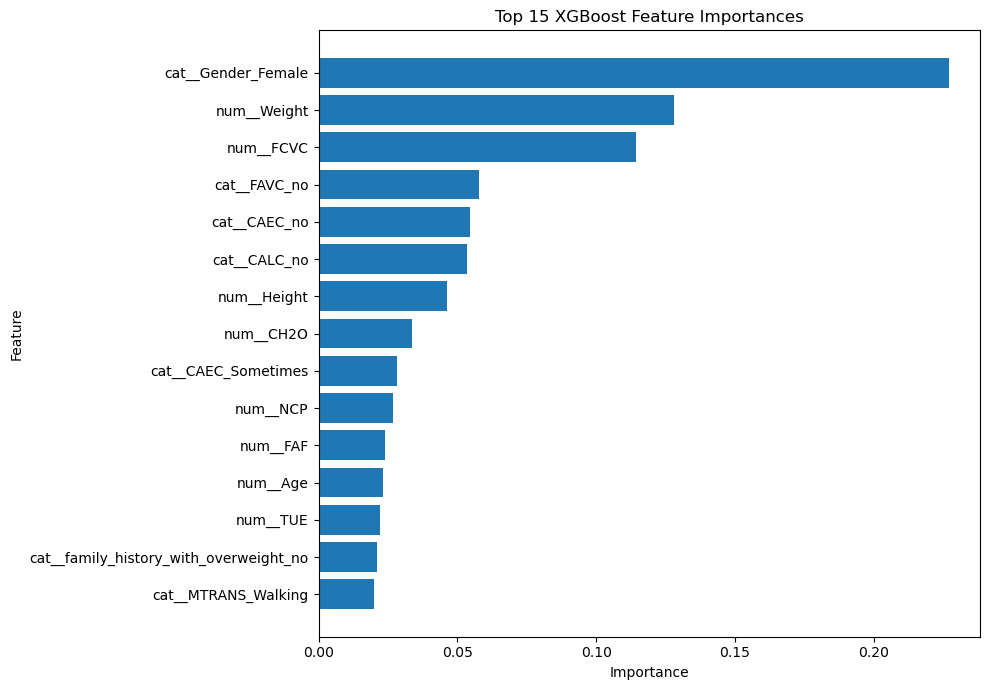

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the tuned XGBoost model
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb_model.feature_importances_
})

# Sort from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("XGBoost Feature Importance")
print("--------------------------")
print(feature_importance.to_string(index=False))

# Plot top 15 features
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

Original Feature Importance
---------------------------
                  Original_Feature  Importance
                     Gender_Female    0.226899
                            Weight    0.128156
                              FCVC    0.114218
                           FAVC_no    0.057877
                           CAEC_no    0.054609
                           CALC_no    0.053419
                            Height    0.046323
                              CH2O    0.033564
                    CAEC_Sometimes    0.028257
                               NCP    0.026802
                               FAF    0.023961
                               Age    0.023150
                               TUE    0.022007
 family_history_with_overweight_no    0.021098
                    MTRANS_Walking    0.020130
                   CALC_Frequently    0.017472
                 MTRANS_Automobile    0.017393
                    CALC_Sometimes    0.017347
                          SMOKE_no    0.016222
    

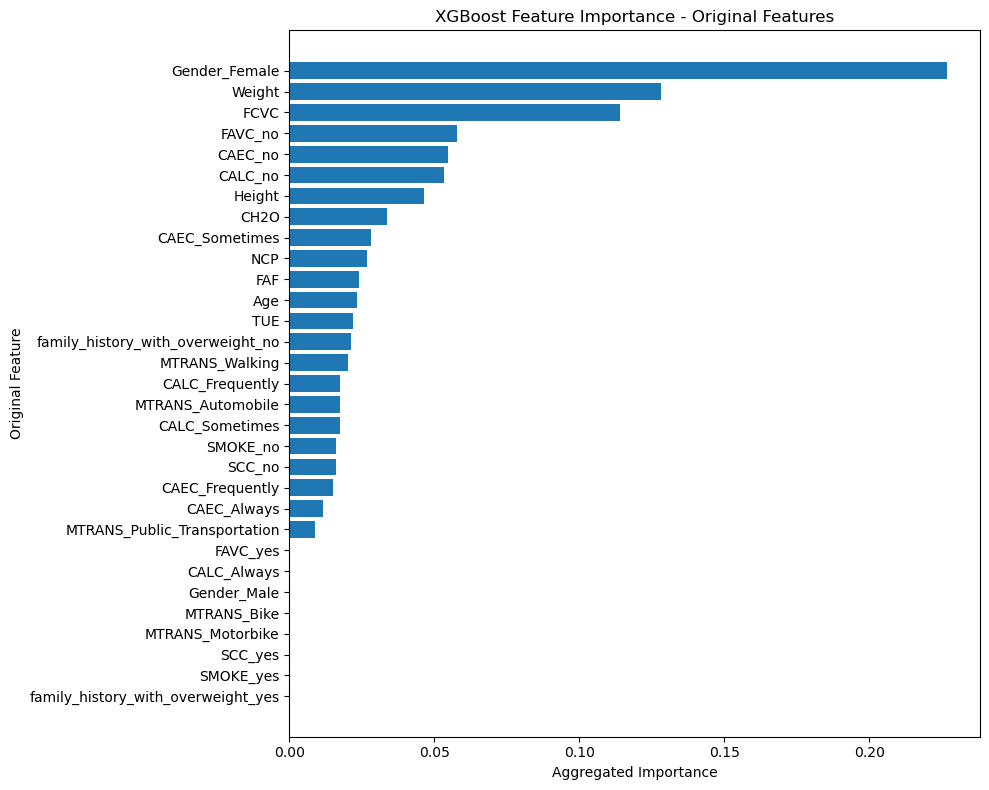

In [18]:
# Create a copy of the feature importance table
original_feature_importance = feature_importance.copy()

# Remove preprocessing prefixes
original_feature_importance["Original_Feature"] = (
    original_feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# For one-hot encoded categorical variables, sum the importance
# of all encoded categories belonging to the same original feature.
original_feature_importance = (
    original_feature_importance
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Original Feature Importance")
print("---------------------------")
print(original_feature_importance.to_string(index=False))

# Plot all 16 original features
plt.figure(figsize=(10, 8))

plt.barh(
    original_feature_importance["Original_Feature"][::-1],
    original_feature_importance["Importance"][::-1]
)

plt.xlabel("Aggregated Importance")
plt.ylabel("Original Feature")
plt.title("XGBoost Feature Importance - Original Features")
plt.tight_layout()
plt.show()

Corrected Original Feature Importance
---------------------------------------
              Original_Feature  Importance
                        Gender    0.226899
                        Weight    0.128156
                          FCVC    0.114218
                          CAEC    0.109273
                          CALC    0.088237
                          FAVC    0.057877
                        Height    0.046323
                        MTRANS    0.046205
                          CH2O    0.033564
                           NCP    0.026802
                           FAF    0.023961
                           Age    0.023150
                           TUE    0.022007
family_history_with_overweight    0.021098
                         SMOKE    0.016222
                           SCC    0.016007

Total Importance: 1.0


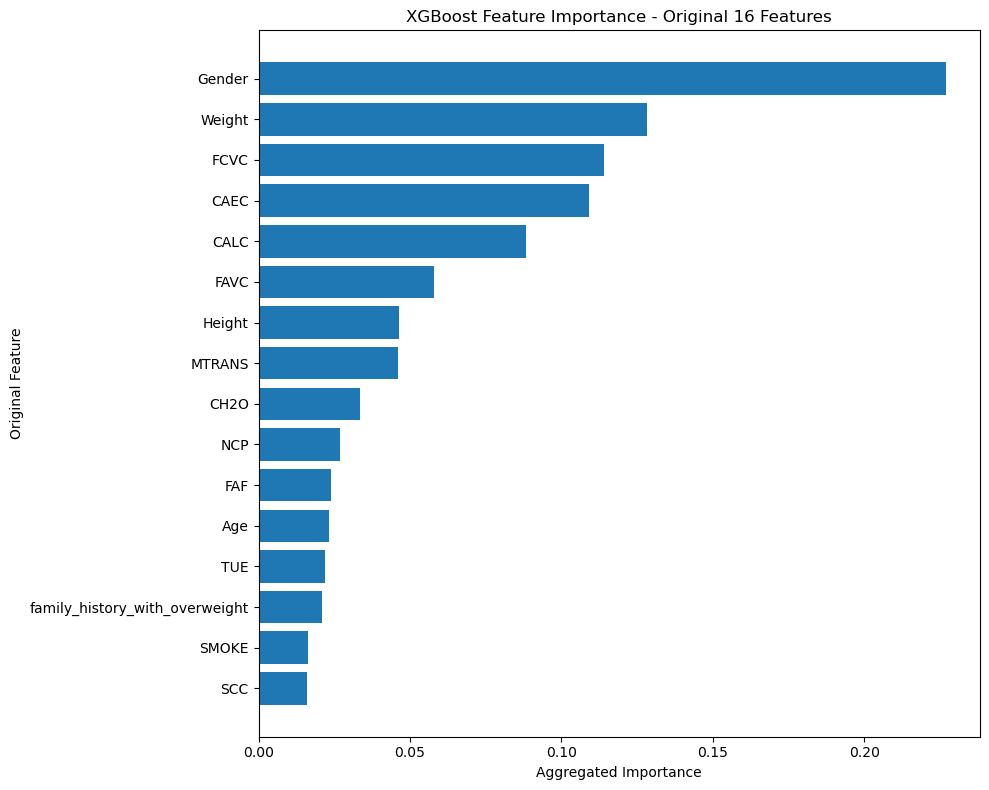

In [19]:
# Correctly aggregate one-hot encoded features back to their
# original 16 features.

original_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb_model.feature_importances_
})

# Map each transformed feature to its original feature
def get_original_feature(feature):
    feature = feature.replace("num__", "").replace("cat__", "")

    # Numerical features
    if feature in numerical_features:
        return feature

    # Categorical features
    for cat_feature in categorical_features:
        if feature.startswith(cat_feature + "_"):
            return cat_feature

    return feature


original_feature_importance["Original_Feature"] = (
    original_feature_importance["Feature"]
    .apply(get_original_feature)
)

# Sum importance of all encoded columns belonging to each
# original categorical feature
original_feature_importance = (
    original_feature_importance
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Corrected Original Feature Importance")
print("---------------------------------------")
print(original_feature_importance.to_string(index=False))

print("\nTotal Importance:",
      round(original_feature_importance["Importance"].sum(), 6))

# Plot all 16 original features
plt.figure(figsize=(10, 8))

plt.barh(
    original_feature_importance["Original_Feature"][::-1],
    original_feature_importance["Importance"][::-1]
)

plt.xlabel("Aggregated Importance")
plt.ylabel("Original Feature")
plt.title("XGBoost Feature Importance - Original 16 Features")
plt.tight_layout()
plt.show()

In [20]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the held-out test set
perm_importance = permutation_importance(
    best_xgb_model,
    X_test_processed,
    y_test_encoded,
    n_repeats=10,
    random_state=42,
    scoring="accuracy",
    n_jobs=-1
)

# Create feature importance table
permutation_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_Std": perm_importance.importances_std
})

# Sort from highest to lowest
permutation_df = permutation_df.sort_values(
    by="Importance_Mean",
    ascending=False
).reset_index(drop=True)

print("Permutation Importance")
print("----------------------")
print(permutation_df.to_string(index=False))

Permutation Importance
----------------------
                                Feature  Importance_Mean  Importance_Std
                            num__Weight         0.737081        0.013636
                            num__Height         0.251914        0.012107
                     cat__Gender_Female         0.137799        0.011077
                           cat__FAVC_no         0.006938        0.001987
                               num__NCP         0.005981        0.003589
                               num__Age         0.004545        0.003110
                              num__CH2O         0.002632        0.002717
                              num__FCVC         0.002153        0.001675
                               num__TUE         0.001914        0.002086
                 cat__MTRANS_Automobile         0.001435        0.001172
                               num__FAF         0.000718        0.002153
                           cat__CALC_no         0.000718        0.001868
     

In [21]:
# Aggregate permutation importance back to the original 16 features

permutation_original = permutation_df.copy()

def get_original_feature_permutation(feature):
    feature = feature.replace("num__", "").replace("cat__", "")

    if feature in numerical_features:
        return feature

    for cat_feature in categorical_features:
        if feature.startswith(cat_feature + "_"):
            return cat_feature

    return feature


permutation_original["Original_Feature"] = (
    permutation_original["Feature"]
    .apply(get_original_feature_permutation)
)

# Sum the mean permutation importance and variance contribution
permutation_original = (
    permutation_original
    .groupby("Original_Feature", as_index=False)
    .agg({
        "Importance_Mean": "sum",
        "Importance_Std": "sum"
    })
    .sort_values("Importance_Mean", ascending=False)
    .reset_index(drop=True)
)

print("Aggregated Permutation Importance")
print("---------------------------------")
print(permutation_original.to_string(index=False))

Aggregated Permutation Importance
---------------------------------
              Original_Feature  Importance_Mean  Importance_Std
                        Weight         0.737081        0.013636
                        Height         0.251914        0.012107
                        Gender         0.137799        0.011077
                          FAVC         0.006938        0.001987
                           NCP         0.005981        0.003589
                           Age         0.004545        0.003110
                          CH2O         0.002632        0.002717
                          FCVC         0.002153        0.001675
                           TUE         0.001914        0.002086
                        MTRANS         0.001435        0.001172
                           FAF         0.000718        0.002153
                           SCC         0.000000        0.000000
                         SMOKE         0.000000        0.000000
                          CAEC      

In [22]:
import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained XGBoost model
joblib.dump(
    best_xgb_model,
    "../models/best_model.pkl"
)

# Save the fitted preprocessing pipeline
joblib.dump(
    preprocessor,
    "../models/preprocessing_pipeline.pkl"
)

print("Models saved successfully!")
print("\nSaved files:")
print("1. ../models/best_model.pkl")
print("2. ../models/preprocessing_pipeline.pkl")

Models saved successfully!

Saved files:
1. ../models/best_model.pkl
2. ../models/preprocessing_pipeline.pkl


In [23]:
import joblib

# Load the saved model and preprocessing pipeline
loaded_model = joblib.load("../models/best_model.pkl")
loaded_preprocessor = joblib.load("../models/preprocessing_pipeline.pkl")

print("Model loaded successfully:", type(loaded_model).__name__)
print("Preprocessor loaded successfully:", type(loaded_preprocessor).__name__)

# Transform the test data using the loaded preprocessor
X_test_loaded = loaded_preprocessor.transform(X_test)

# Make predictions using the loaded model
y_pred_loaded_encoded = loaded_model.predict(X_test_loaded)

# Convert predictions back to original class labels
y_pred_loaded = pd.Series(
    y_pred_loaded_encoded
).map(int_to_class)

# Verify predictions match our final model predictions
predictions_match = (
    y_pred_loaded.to_numpy() == y_pred_tuned_xgb.to_numpy()
).all()

loaded_accuracy = accuracy_score(
    y_test,
    y_pred_loaded
)

print("\nLoaded Model Verification")
print("-------------------------")
print("Predictions match original model:", predictions_match)
print(f"Loaded model test accuracy: {loaded_accuracy * 100:.2f}%")

Model loaded successfully: XGBClassifier
Preprocessor loaded successfully: ColumnTransformer

Loaded Model Verification
-------------------------
Predictions match original model: True
Loaded model test accuracy: 96.89%
